# Lab 6: Attention Mechanism & Heatmap Visualization
**Objective:** Implement a Seq2Seq model with Bahdanau (additive) attention and visualize the attention alignment heatmaps.
**Task:** Toy reverse-sequence task with attention.

In [1]:
!pip install torch numpy matplotlib seaborn --quiet

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import random

torch.manual_seed(42)
random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cpu


## 1. Data — Number Reversal Task

In [3]:
VOCAB = 12  # 0-9 + SOS(10) + EOS(11)
SOS, EOS = 10, 11
SEQ_LEN = 8

def make_pairs(n=3000):
    pairs = []
    for _ in range(n):
        seq = [random.randint(0, 9) for _ in range(SEQ_LEN)]
        pairs.append((seq, list(reversed(seq))))
    return pairs

pairs = make_pairs()
train_p, test_p = pairs[:2400], pairs[2400:]
print(f'Example: {train_p[0][0]} → {train_p[0][1]}')

Example: [1, 0, 4, 3, 3, 2, 1, 8] → [8, 1, 2, 3, 3, 4, 0, 1]


## 2. Attention Mechanism (Bahdanau)

In [4]:
class BahdanauAttention(nn.Module):
    """Additive (Bahdanau) Attention."""
    def __init__(self, hidden_size):
        super().__init__()
        self.W_q = nn.Linear(hidden_size, hidden_size, bias=False)
        self.W_k = nn.Linear(hidden_size, hidden_size, bias=False)
        self.v   = nn.Linear(hidden_size, 1, bias=False)

    def forward(self, query, keys):
        """
        query: (B, H)  — decoder hidden state
        keys:  (B, T, H) — encoder outputs
        returns: context (B, H), weights (B, T)
        """
        q = self.W_q(query).unsqueeze(1)          # (B, 1, H)
        k = self.W_k(keys)                         # (B, T, H)
        energy = self.v(torch.tanh(q + k)).squeeze(-1)  # (B, T)
        weights = F.softmax(energy, dim=-1)        # (B, T)
        context = (weights.unsqueeze(-1) * keys).sum(1)  # (B, H)
        return context, weights

class EncoderAttn(nn.Module):
    def __init__(self, vocab, embed_dim, hidden_size):
        super().__init__()
        self.embed = nn.Embedding(vocab, embed_dim)
        self.lstm  = nn.LSTM(embed_dim, hidden_size, batch_first=True)
    def forward(self, x):
        enc_out, (h, c) = self.lstm(self.embed(x))
        return enc_out, (h, c)

class DecoderAttn(nn.Module):
    def __init__(self, vocab, embed_dim, hidden_size):
        super().__init__()
        self.embed   = nn.Embedding(vocab, embed_dim)
        self.attn    = BahdanauAttention(hidden_size)
        self.lstm    = nn.LSTM(embed_dim + hidden_size, hidden_size, batch_first=True)
        self.fc      = nn.Linear(hidden_size, vocab)
    def forward(self, token, hidden, enc_out):
        embed = self.embed(token.unsqueeze(1))          # (B, 1, E)
        h_dec = hidden[0].squeeze(0)                    # (B, H)
        context, attn_w = self.attn(h_dec, enc_out)     # (B,H), (B,T)
        lstm_in = torch.cat([embed, context.unsqueeze(1)], dim=-1)
        out, hidden = self.lstm(lstm_in, hidden)
        logit = self.fc(out.squeeze(1))                 # (B, V)
        return logit, hidden, attn_w

HIDDEN = 128
encoder = EncoderAttn(VOCAB, 32, HIDDEN).to(device)
decoder = DecoderAttn(VOCAB, 32, HIDDEN).to(device)
print('Models created.')

Models created.


## 3. Training

In [5]:
params = list(encoder.parameters()) + list(decoder.parameters())
optimizer = optim.Adam(params, lr=0.001)
criterion = nn.CrossEntropyLoss()

def batch_iter(pairs, bs=64):
    random.shuffle(pairs)
    for i in range(0, len(pairs), bs):
        b = pairs[i:i+bs]
        src = torch.tensor([p[0] for p in b], dtype=torch.long).to(device)
        trg = torch.tensor([[SOS]+p[1] for p in b], dtype=torch.long).to(device)
        yield src, trg

losses = []
for epoch in range(40):
    encoder.train(); decoder.train()
    total = 0
    for src, trg in batch_iter(train_p):
        optimizer.zero_grad()
        enc_out, hidden = encoder(src)
        token = trg[:, 0]
        loss  = 0
        for t in range(1, trg.size(1)):
            logit, hidden, _ = decoder(token, hidden, enc_out)
            loss += criterion(logit, trg[:, t])
            token = trg[:, t] if random.random() < 0.5 else logit.argmax(1)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(params, 1.0)
        optimizer.step()
        total += loss.item()
    losses.append(total)
    if (epoch+1) % 10 == 0:
        print(f'Epoch {epoch+1}/40 | Loss: {total:.2f}')

Epoch 10/40 | Loss: 3.17
Epoch 20/40 | Loss: 0.35
Epoch 30/40 | Loss: 0.32
Epoch 40/40 | Loss: 0.04


## 4. Attention Heatmap Visualization

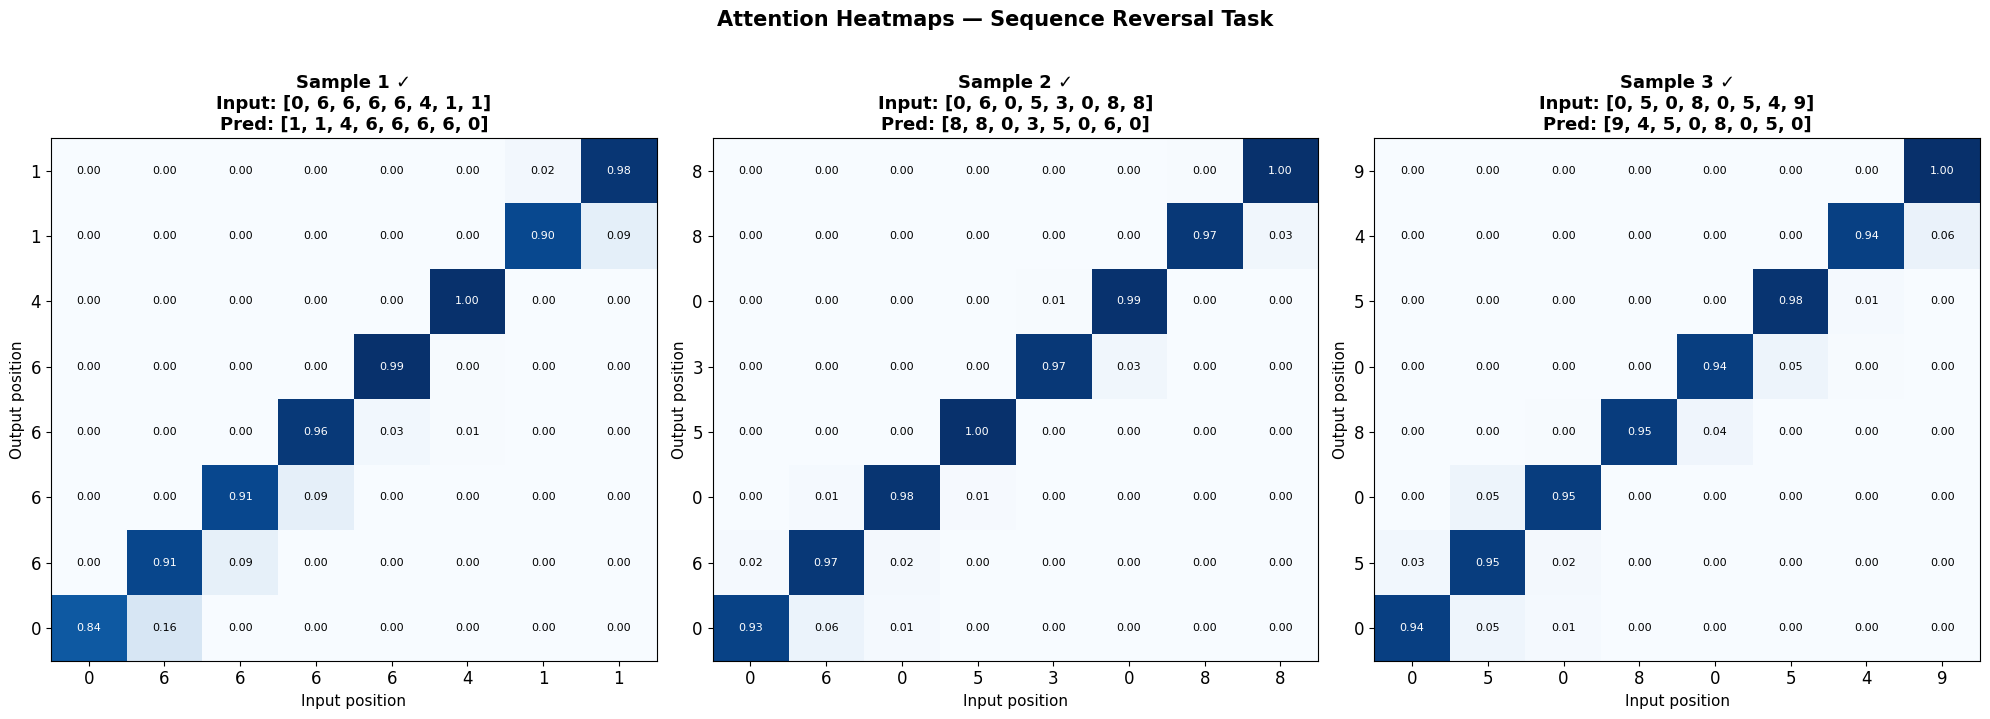

Heatmap saved as lab6_attention_heatmap.png


In [6]:
def get_attention(src_seq):
    encoder.eval(); decoder.eval()
    src = torch.tensor([src_seq], dtype=torch.long).to(device)
    with torch.no_grad():
        enc_out, hidden = encoder(src)
        token = torch.tensor([SOS]).to(device)
        attn_weights = []
        preds = []
        for _ in range(SEQ_LEN):
            logit, hidden, w = decoder(token, hidden, enc_out)
            attn_weights.append(w.squeeze(0).cpu().numpy())
            token = logit.argmax(1)
            preds.append(token.item())
    return preds, np.array(attn_weights)  # (T_out, T_in)

def plot_attention(src, pred, attn, ax, title=''):
    src_labels  = [str(x) for x in src]
    pred_labels = [str(x) for x in pred]
    im = ax.imshow(attn, cmap='Blues', aspect='auto', vmin=0, vmax=1)
    ax.set_xticks(range(len(src_labels)));  ax.set_xticklabels(src_labels, fontsize=12)
    ax.set_yticks(range(len(pred_labels))); ax.set_yticklabels(pred_labels, fontsize=12)
    ax.set_xlabel('Input position',  fontsize=11)
    ax.set_ylabel('Output position', fontsize=11)
    ax.set_title(title, fontsize=13, fontweight='bold')
    for i in range(attn.shape[0]):
        for j in range(attn.shape[1]):
            ax.text(j, i, f'{attn[i,j]:.2f}', ha='center', va='center',
                    fontsize=8, color='white' if attn[i,j] > 0.5 else 'black')
    return im

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
samples = random.sample(test_p, 3)

for i, (src_seq, trg_seq) in enumerate(samples):
    preds, attn = get_attention(src_seq)
    correct = '✓' if preds == trg_seq else '✗'
    plot_attention(src_seq, preds, attn, axes[i],
                   title=f'Sample {i+1} {correct}\nInput: {src_seq}\nPred: {preds}')

plt.suptitle('Attention Heatmaps — Sequence Reversal Task', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('lab6_attention_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Heatmap saved as lab6_attention_heatmap.png')